# 01 — Keşifsel Veri Analizi (EDA)
Kaggle Chest X-Ray veri setini incele, sınıf dağılımını görselleştir.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

# Veri kök dizini
DATA_DIR = Path('../data/chest_xray/chest_xray')
TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR   = DATA_DIR / 'val'
TEST_DIR  = DATA_DIR / 'test'

print('Veri dizini:', DATA_DIR.resolve())

Veri dizini: C:\Users\pc\DeepLearning\4.proje\data\chest_xray\chest_xray


## 1. Sınıf Dağılımı

In [2]:
def count_images(root_dir):
    counts = {}
    for cls in ['NORMAL', 'PNEUMONIA']:
        cls_dir = root_dir / cls
        if cls_dir.exists():
            counts[cls] = len(list(cls_dir.glob('*.jpeg')) + list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.png')))
        else:
            counts[cls] = 0
    return counts

for split_name, split_dir in [('Train', TRAIN_DIR), ('Val', VAL_DIR), ('Test', TEST_DIR)]:
    c = count_images(split_dir)
    total = sum(c.values())
    print(f"{split_name:5s}: NORMAL={c['NORMAL']:5d}  PNEUMONIA={c['PNEUMONIA']:5d}  Toplam={total}")

Train: NORMAL= 1341  PNEUMONIA= 3875  Toplam=5216
Val  : NORMAL=    8  PNEUMONIA=    8  Toplam=16
Test : NORMAL=  234  PNEUMONIA=  390  Toplam=624


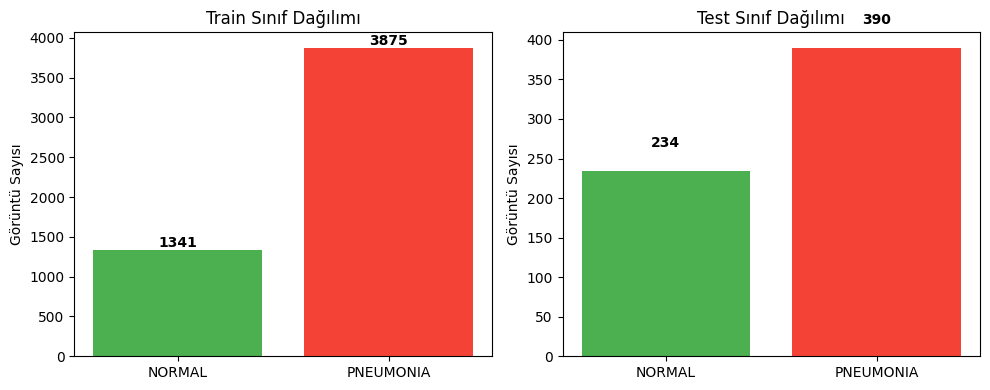

In [3]:
train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ['#4CAF50', '#F44336']

for ax, (split_name, counts) in zip(axes, [('Train', train_counts), ('Test', test_counts)]):
    bars = ax.bar(counts.keys(), counts.values(), color=colors)
    ax.set_title(f'{split_name} Sınıf Dağılımı')
    ax.set_ylabel('Görüntü Sayısı')
    for bar, val in zip(bars, counts.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/figures/class_distribution.png', dpi=150)
plt.show()

## 2. Örnek Görüntüler (Normal vs Pneumonia)

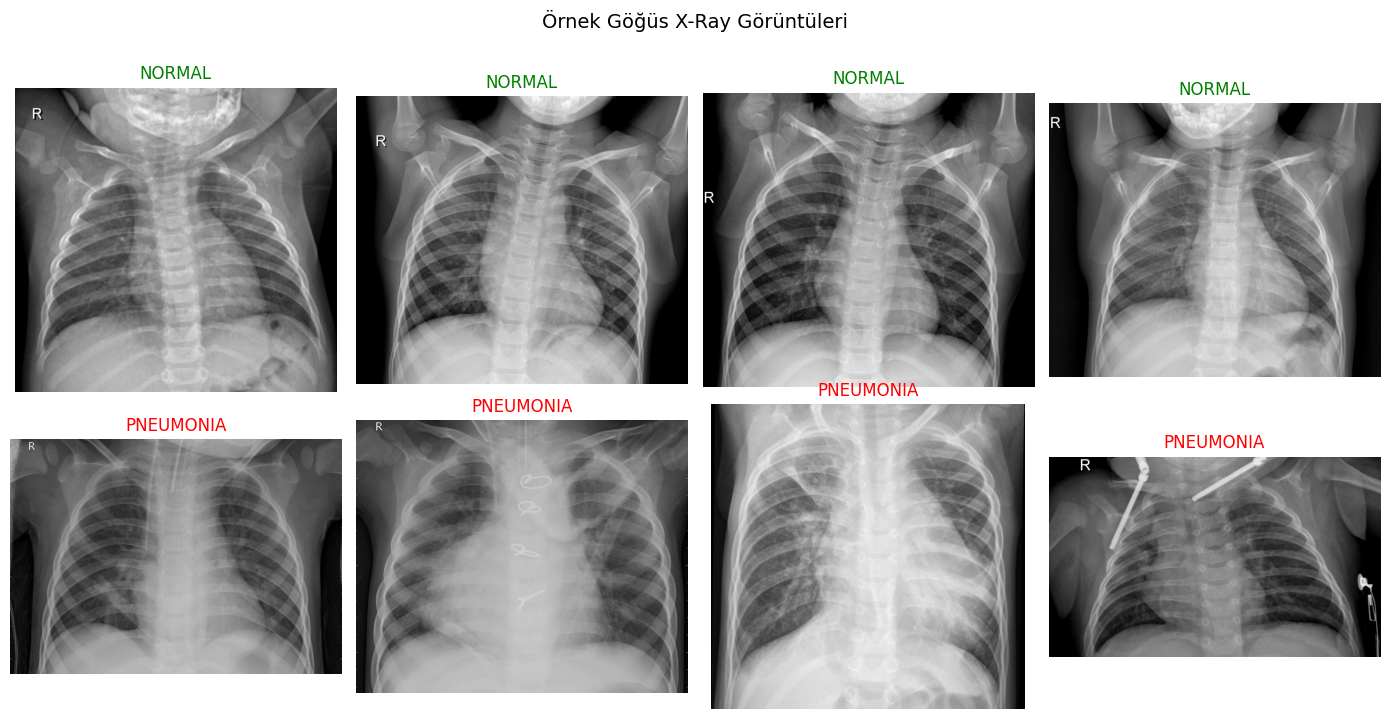

In [4]:
import cv2
import random

def sample_images(cls_dir, n=4):
    paths = list(Path(cls_dir).glob('*.jpeg')) + list(Path(cls_dir).glob('*.jpg'))
    return random.sample(paths, min(n, len(paths)))

normal_imgs    = sample_images(TRAIN_DIR / 'NORMAL', 4)
pneumonia_imgs = sample_images(TRAIN_DIR / 'PNEUMONIA', 4)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for col, path in enumerate(normal_imgs):
    img = cv2.imread(str(path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[0, col].imshow(img, cmap='gray')
    axes[0, col].axis('off')
    axes[0, col].set_title('NORMAL', color='green')

for col, path in enumerate(pneumonia_imgs):
    img = cv2.imread(str(path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[1, col].imshow(img, cmap='gray')
    axes[1, col].axis('off')
    axes[1, col].set_title('PNEUMONIA', color='red')

plt.suptitle('Örnek Göğüs X-Ray Görüntüleri', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../results/figures/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Stratified Validation Split Oluştur
Orijinal 16-görüntülük val setini atlayıp eğitim setinden %10 ayırıyoruz.

In [5]:
sys.path.insert(0, '../src')
from preprocessing import create_stratified_val_split

# Bu hücreyi yalnızca BİR KEZ çalıştırın!
# val/ dizini zaten doluysa tekrar çalıştırmayın.
val_already_split = (VAL_DIR / 'NORMAL').exists() and len(list((VAL_DIR / 'NORMAL').glob('*'))) > 16

if not val_already_split:
    train_paths, train_labels, val_paths, val_labels = create_stratified_val_split(
        str(TRAIN_DIR), str(VAL_DIR), val_ratio=0.10
    )
else:
    print('Validation seti zaten oluşturulmuş, atlanıyor.')

Yeni validation seti: 522 görüntü
  NORMAL: 134, PNEUMONIA: 388


## 4. Görüntü Boyut Dağılımı

Genişlik — min:502  max:2538  ort:1442
Yükseklik — min:307 max:2066 ort:1086


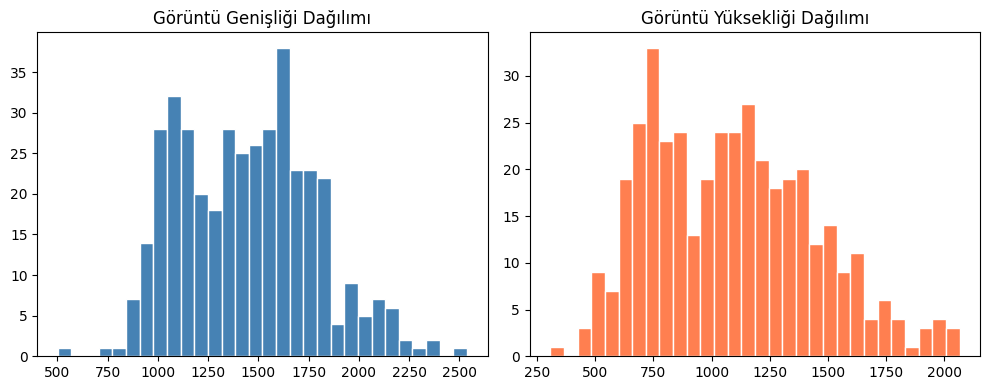

In [6]:
widths, heights = [], []
all_paths = list((TRAIN_DIR / 'NORMAL').glob('*.jpeg'))[:200] + \
            list((TRAIN_DIR / 'PNEUMONIA').glob('*.jpeg'))[:200]

for p in all_paths:
    img = cv2.imread(str(p))
    if img is not None:
        h, w = img.shape[:2]
        heights.append(h)
        widths.append(w)

print(f'Genişlik — min:{min(widths)}  max:{max(widths)}  ort:{np.mean(widths):.0f}')
print(f'Yükseklik — min:{min(heights)} max:{max(heights)} ort:{np.mean(heights):.0f}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(widths, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Görüntü Genişliği Dağılımı')
axes[1].hist(heights, bins=30, color='coral', edgecolor='white')
axes[1].set_title('Görüntü Yüksekliği Dağılımı')
plt.tight_layout()
plt.savefig('../results/figures/image_size_dist.png', dpi=150)
plt.show()